In [1]:
import digitalhub as dh
import pandas as pd
import numpy as np
import requests
import os
!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt
!pip install geopandas
import geopandas as gpd
!pip install shapely
from shapely.geometry import LineString, Point
import matplotlib.pyplot as plt
!pip install contextily
import contextily as ctx
import ast

PROJECT = "test-otp-v2"
project = dh.get_or_create_project(PROJECT)

In [2]:
zoi: str = "restrictedAv"  ## Choose between "allBologna" and "restrictedAv"
method: str = "extended" ## Choose between "simplified" and "extended"
version: str = "20251003"

df_car_trans_di = project.get_dataitem(f"otp_results_{method}_{zoi}_CAR_PARK_TRANSIT_v{version}")
df_car_trans = df_car_trans_di.as_df()

In [3]:
df_car_trans.columns

Index(['row_index', 'origin_lat', 'origin_lon', 'from', 'dest_lat', 'dest_lon',
       'to', 'origin_lat_tmp', 'origin_lon_tmp', 'dest_lat_tmp',
       'dest_lon_tmp', 'n_iter', 'status', 'duration_seconds',
       'walk_time_seconds', 'number_of_legs', 'transport_modes',
       'transport_mode_sequences', 'transport_durations',
       'transport_percentages', 'number_of_transit_transfers', 'start_time',
       'end_time', 'mode_change_points', 'mode_change_coordinates',
       'mode_change_names', 'transport_sequence'],
      dtype='object')

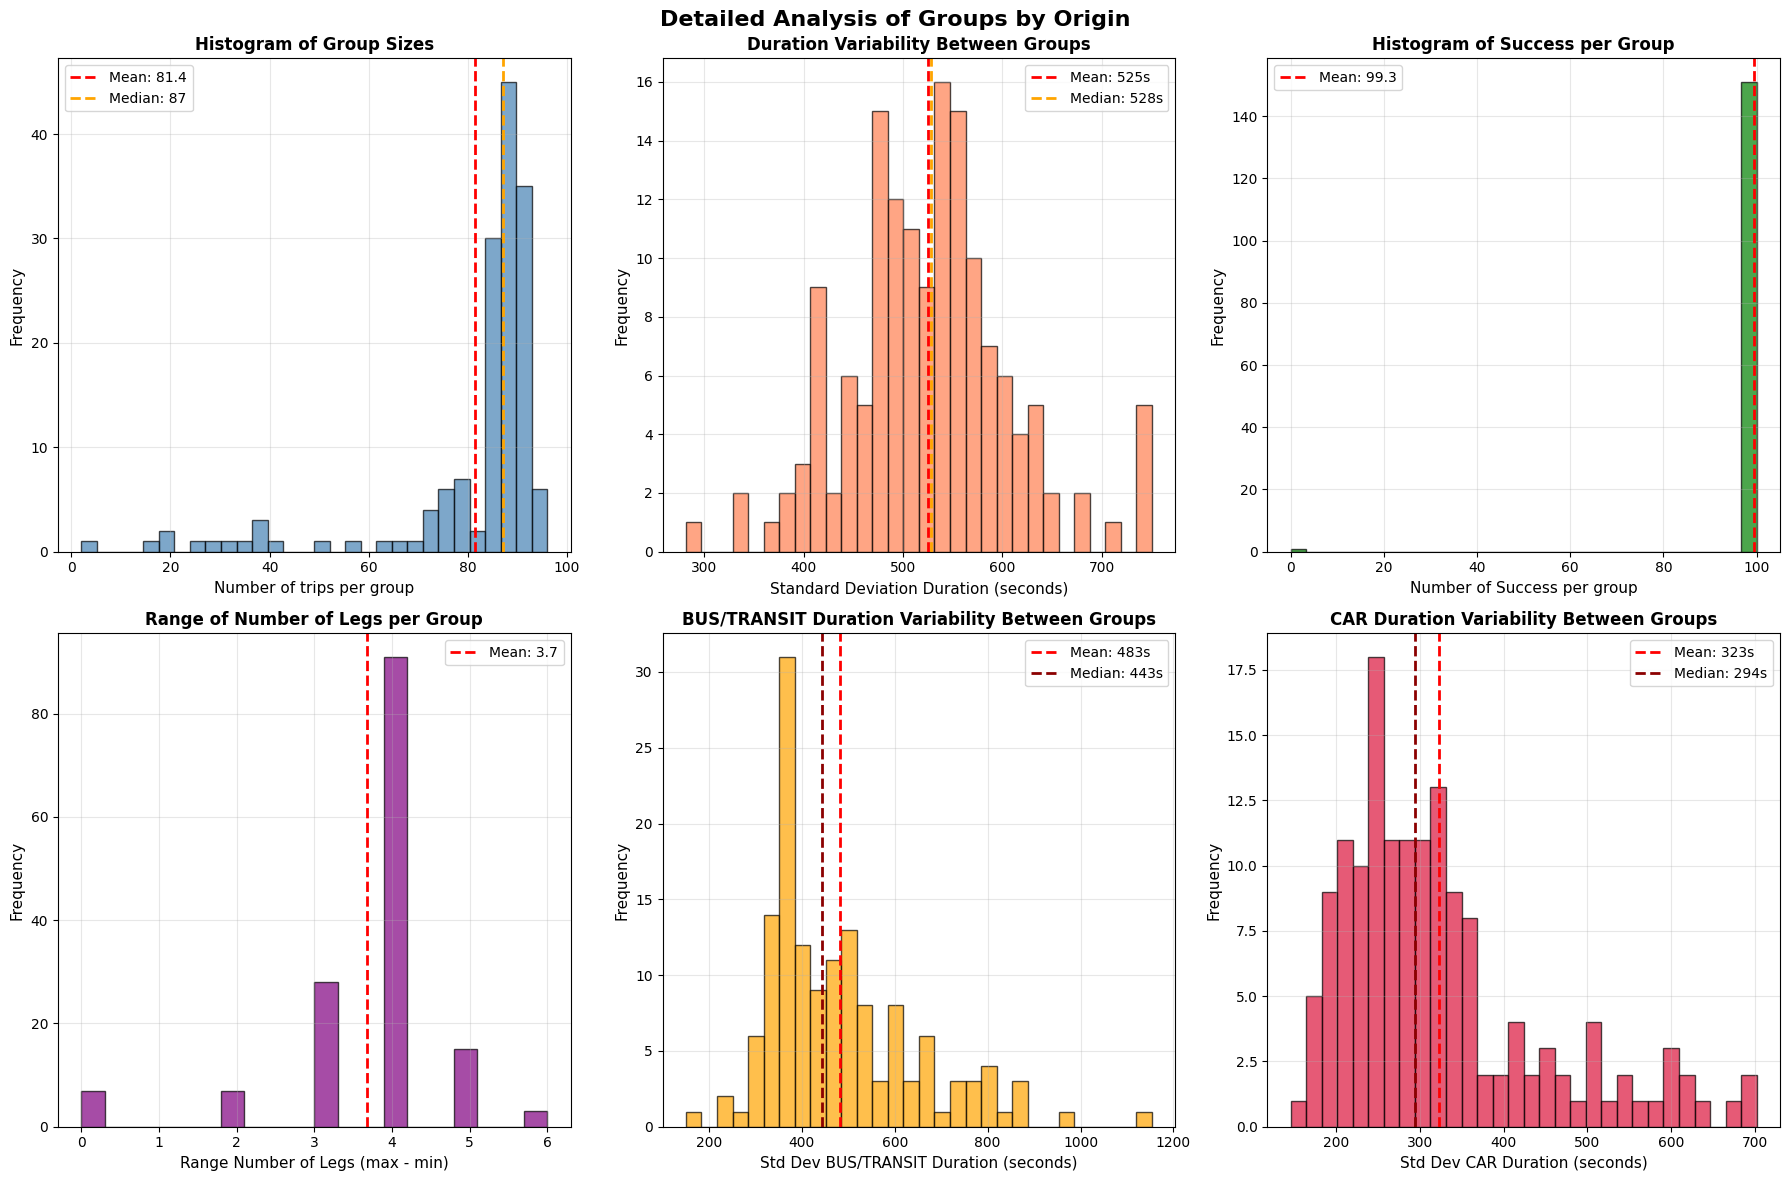

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Function to calculate duration by specific mode
def get_duration_by_mode(row, mode_target):
    """Extracts total duration for a specific transport mode"""
    modes = row['transport_modes']
    durations = row['transport_durations']
    
    total_duration = 0
    for mode, duration in zip(modes, durations):
        if mode.upper() in mode_target:
            total_duration += duration
    
    return total_duration

# Calculate BUS/TRANSIT and CAR duration for each row
df_car_trans['bus_transit_duration'] = df_car_trans.apply(
    lambda row: get_duration_by_mode(row, ['BUS', 'TRANSIT']), axis=1
)
df_car_trans['car_duration'] = df_car_trans.apply(
    lambda row: get_duration_by_mode(row, ['CAR']), axis=1
)

# Group by origin
grouped = df_car_trans.groupby(['origin_lat', 'origin_lon'])

# Calculate metrics per group
group_stats = []

for (lat, lon), group in grouped:
    n_trips = len(group)
    
    # Duration
    duration_mean = group['duration_seconds'].mean()
    duration_std = group['duration_seconds'].std()
    
    # Success status
    n_success = (group['status'] == 'success').sum() / (group['status'] != 'nothing').sum() * 100
    
    # Legs range
    legs_range = group['number_of_legs'].max() - group['number_of_legs'].min()
    
    # BUS/TRANSIT duration variability
    bus_transit_mean = group['bus_transit_duration'].mean()
    bus_transit_std = group['bus_transit_duration'].std()
    
    # CAR duration variability
    car_mean = group['car_duration'].mean()
    car_std = group['car_duration'].std()
    
    group_stats.append({
        'origin_lat': lat,
        'origin_lon': lon,
        'n_trips': n_trips,
        'duration_std': duration_std,
        'n_success': n_success,
        'legs_range': legs_range,
        'bus_transit_std': bus_transit_std,
        'car_std': car_std
    })

df_groups = pd.DataFrame(group_stats)

# Filter groups with at least 2 trips to calculate variability
df_groups_filtered = df_groups[df_groups['n_trips'] >= 2].copy()

# Create figure with 6 subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Detailed Analysis of Groups by Origin', fontsize=16, fontweight='bold')

# 1. Histogram of group sizes
ax1 = axes[0, 0]
ax1.hist(df_groups['n_trips'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xlabel('Number of trips per group', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Histogram of Group Sizes', fontsize=12, fontweight='bold')
ax1.axvline(df_groups['n_trips'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f"Mean: {df_groups['n_trips'].mean():.1f}")
ax1.axvline(df_groups['n_trips'].median(), color='orange', linestyle='--', 
            linewidth=2, label=f"Median: {df_groups['n_trips'].median():.0f}")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Histogram of duration variability between groups
ax2 = axes[0, 1]
duration_std_clean = df_groups_filtered['duration_std'].dropna()
ax2.hist(duration_std_clean, bins=30, edgecolor='black', alpha=0.7, color='coral')
ax2.set_xlabel('Standard Deviation Duration (seconds)', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Duration Variability Between Groups', fontsize=12, fontweight='bold')
ax2.axvline(duration_std_clean.mean(), color='red', linestyle='--', 
            linewidth=2, label=f"Mean: {duration_std_clean.mean():.0f}s")
ax2.axvline(duration_std_clean.median(), color='orange', linestyle='--', 
            linewidth=2, label=f"Median: {duration_std_clean.median():.0f}s")
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Histogram of number of "success" per group
ax3 = axes[0, 2]
ax3.hist(df_groups['n_success'], bins=30, edgecolor='black', alpha=0.7, color='green')
ax3.set_xlabel('Number of Success per group', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.set_title('Histogram of Success per Group', fontsize=12, fontweight='bold')
ax3.axvline(df_groups['n_success'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f"Mean: {df_groups['n_success'].mean():.1f}")
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Histogram of range of number of legs per group
ax4 = axes[1, 0]
legs_range_clean = df_groups_filtered['legs_range'].dropna()
ax4.hist(legs_range_clean, bins=20, edgecolor='black', alpha=0.7, color='purple')
ax4.set_xlabel('Range Number of Legs (max - min)', fontsize=11)
ax4.set_ylabel('Frequency', fontsize=11)
ax4.set_title('Range of Number of Legs per Group', fontsize=12, fontweight='bold')
ax4.axvline(legs_range_clean.mean(), color='red', linestyle='--', 
            linewidth=2, label=f"Mean: {legs_range_clean.mean():.1f}")
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. BUS/TRANSIT duration variability between groups
ax5 = axes[1, 1]
bus_std_clean = df_groups_filtered['bus_transit_std'].dropna()
bus_std_clean = bus_std_clean[bus_std_clean > 0]  # Remove zeros
ax5.hist(bus_std_clean, bins=30, edgecolor='black', alpha=0.7, color='orange')
ax5.set_xlabel('Std Dev BUS/TRANSIT Duration (seconds)', fontsize=11)
ax5.set_ylabel('Frequency', fontsize=11)
ax5.set_title('BUS/TRANSIT Duration Variability Between Groups', fontsize=12, fontweight='bold')
if len(bus_std_clean) > 0:
    ax5.axvline(bus_std_clean.mean(), color='red', linestyle='--', 
                linewidth=2, label=f"Mean: {bus_std_clean.mean():.0f}s")
    ax5.axvline(bus_std_clean.median(), color='darkred', linestyle='--', 
                linewidth=2, label=f"Median: {bus_std_clean.median():.0f}s")
    ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. CAR duration variability between groups
ax6 = axes[1, 2]
car_std_clean = df_groups_filtered['car_std'].dropna()
car_std_clean = car_std_clean[car_std_clean > 0]  # Remove zeros
ax6.hist(car_std_clean, bins=30, edgecolor='black', alpha=0.7, color='crimson')
ax6.set_xlabel('Std Dev CAR Duration (seconds)', fontsize=11)
ax6.set_ylabel('Frequency', fontsize=11)
ax6.set_title('CAR Duration Variability Between Groups', fontsize=12, fontweight='bold')
if len(car_std_clean) > 0:
    ax6.axvline(car_std_clean.mean(), color='red', linestyle='--', 
                linewidth=2, label=f"Mean: {car_std_clean.mean():.0f}s")
    ax6.axvline(car_std_clean.median(), color='darkred', linestyle='--', 
                linewidth=2, label=f"Median: {car_std_clean.median():.0f}s")
    ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('group_analysis_detailed.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Print summary statistics
print(f"\n1. GROUP SIZES:")
print(f"   Total groups: {len(df_groups)}")
print(f"   Mean n. dest per group: {df_groups['n_trips'].mean():.2f}")
print(f"   Median n. dest per group: {df_groups['n_trips'].median():.0f}")
print(f"   Max n. dest in a group: {df_groups['n_trips'].max():.0f}")

print(f"\n2. DURATION VARIABILITY:")
print(f"   Mean std dev duration: {duration_std_clean.mean():.2f} seconds")
print(f"   Median std dev duration: {duration_std_clean.median():.2f} seconds")

print(f"\n3. STATUS SUCCESS:")
print(f"   Mean success per group: {df_groups['n_success'].mean():.2f}")
print(f"   Total success: {df_groups['n_success'].sum():.0f}")
print(f"   Average success rate: {(df_groups['n_success'].sum() / df_groups['n_trips'].sum() * 100):.1f}%")

print(f"\n4. LEGS RANGE:")
print(f"   Mean legs range: {legs_range_clean.mean():.2f}")
print(f"   Max legs range: {legs_range_clean.max():.0f}")

print(f"\n5. BUS/TRANSIT VARIABILITY:")
print(f"   N. orig zones with BUS/TRANSIT: {len(bus_std_clean)} on {len(df_groups)}")
if len(bus_std_clean) > 0:
    print(f"   Mean std dev: {bus_std_clean.mean():.2f} seconds")
    print(f"   Median std dev: {bus_std_clean.median():.2f} seconds")

print(f"\n6. CAR VARIABILITY:")
print(f"   N. orig zones with CAR: {len(car_std_clean)} on {len(df_groups)}")
if len(car_std_clean) > 0:
    print(f"   Mean std dev: {car_std_clean.mean():.2f} seconds")
    print(f"   Median std dev: {car_std_clean.median():.2f} seconds")


1. GROUP SIZES:
   Total groups: 152
   Mean n. dest per group: 81.39
   Median n. dest per group: 87
   Max n. dest in a group: 96

2. DURATION VARIABILITY:
   Mean std dev duration: 525.10 seconds
   Median std dev duration: 528.20 seconds

3. STATUS SUCCESS:
   Mean success per group: 99.34
   Total success: 15100
   Average success rate: 122.1%

4. LEGS RANGE:
   Mean legs range: 3.68
   Max legs range: 6

5. BUS/TRANSIT VARIABILITY:
   N. orig zones with BUS/TRANSIT: 145 on 152
   Mean std dev: 482.76 seconds
   Median std dev: 443.06 seconds

6. CAR VARIABILITY:
   N. orig zones with CAR: 151 on 152
   Mean std dev: 323.17 seconds
   Median std dev: 294.08 seconds


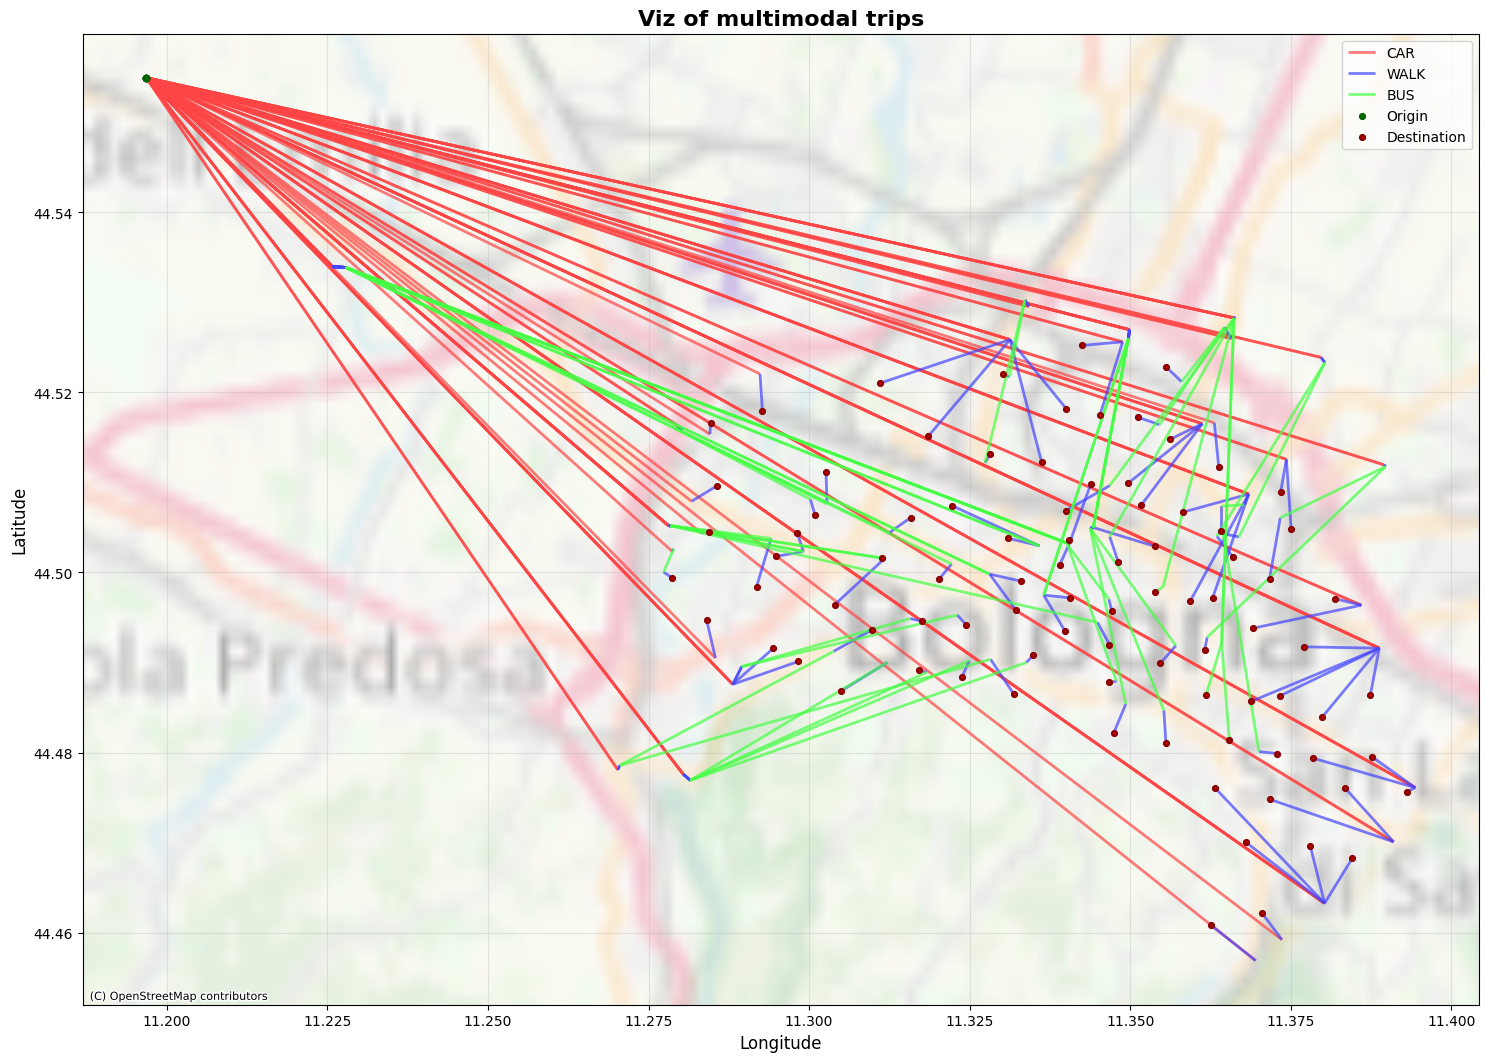

In [12]:
# For 1 origin, plot the trip segments per mode
df_sample = df_car_trans[df_car_trans["status"]=="success"]
df_sample = df_sample[df_sample['from'] == df_sample["from"].unique()[0]]

# Color map for modes
transport_colors = {
    'CAR': '#FF4444',
    'WALK': '#4444FF',
    'BUS': '#44FF44',
    'TRANSIT': '#44FF44'
}

# For each trip in the sample, create the linestring of the trip
segments_list = []

for idx, row in df_sample.iterrows():
    coords_str = row['mode_change_coordinates']
    transport_modes = row['transport_modes']
    
    # Converti la stringa in lista di tuple
    if isinstance(coords_str, str):
        coords = ast.literal_eval(coords_str)
    else:
        coords = coords_str
    
    # Crea un segmento per ogni tratta del viaggio
    for i in range(len(coords) - 1):
        start_point = coords[i]
        end_point = coords[i + 1]
        
        # Se i punti sono stringhe, convertili in tuple
        if isinstance(start_point, str):
            start_point = ast.literal_eval(start_point)
        if isinstance(end_point, str):
            end_point = ast.literal_eval(end_point)
        
        # Determina la modalità di trasporto per questo segmento
        if i < len(transport_modes):
            mode = transport_modes[i]
            color = transport_colors.get(mode, '#888888')
        else:
            mode = 'UNKNOWN'
            color = '#888888'
        
        # Crea LineString per il segmento (nota: shapely usa (lon, lat))
        line = LineString([(start_point[1], start_point[0]),  (end_point[1], end_point[0])])
        
        segments_list.append({'geometry': line,'trip_id': idx,'segment_id': i,'mode': mode,'color': color})

# Create the geodataframe
gdf_segments = gpd.GeoDataFrame(segments_list, crs='EPSG:4326')

# Create marker for OD
origins = []
destinations = []

for idx, row in df_sample.iterrows():
    coords_str = row['mode_change_coordinates']
    
    if isinstance(coords_str, str):
        coords = ast.literal_eval(coords_str)
    else:
        coords = coords_str
    
    # Converti i punti se sono stringhe
    first_coord = coords[0]
    last_coord = coords[-1]
    
    if isinstance(first_coord, str):
        first_coord = ast.literal_eval(first_coord)
    if isinstance(last_coord, str):
        last_coord = ast.literal_eval(last_coord)
    
    # Origin
    origins.append({'geometry': Point(first_coord[1], first_coord[0]), 'trip_id': idx,'type': 'origin'})
    # Dest
    destinations.append({'geometry': Point(last_coord[1], last_coord[0]),'trip_id': idx, 'type': 'destination'})

gdf_origins = gpd.GeoDataFrame(origins, crs='EPSG:4326')
gdf_destinations = gpd.GeoDataFrame(destinations, crs='EPSG:4326')

# PLOT
fig, ax = plt.subplots(figsize=(15, 12))

# Add trip segments
for mode in gdf_segments['mode'].unique():
    gdf_mode = gdf_segments[gdf_segments['mode'] == mode]
    color = gdf_mode.iloc[0]['color']
    gdf_mode.plot(ax=ax, color=color, linewidth=2, alpha=0.7, label=mode)

# Plot OD points
gdf_origins.plot(ax=ax, color='green', markersize=10, 
                 label='Origin', zorder=5, edgecolor='darkgreen', linewidth=2)
gdf_destinations.plot(ax=ax, color='red', markersize=10, 
                      label='Destination', zorder=5, edgecolor='darkred', linewidth=2)

# Add basemap
ctx.add_basemap(ax, crs=gdf_segments.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik, zoom=10, alpha=0.4)

# Plot configuration
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Viz of multimodal trips', fontsize=16, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


RMSE [seconds]: 396.28348199764406
MAE [seconds]: 344.4659541726406


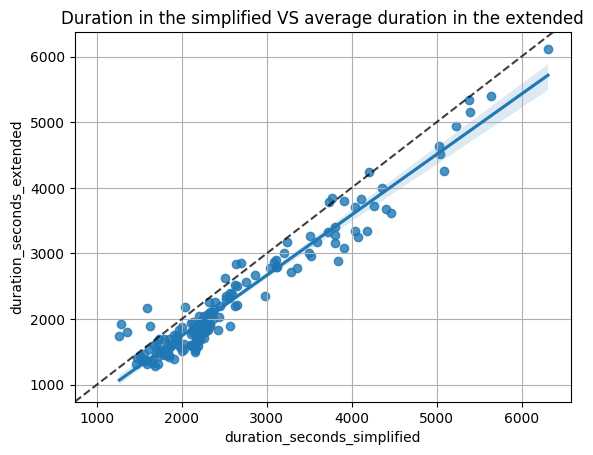

In [20]:
# Now compare the difference between trip duration in the simplified with average trip duration in the extended

zoi: str = "restrictedAv"  ## Choose between "allBologna" and "restrictedAv"
method: str = "simplified"
version: str = "20250926"

df_times_simplified_di = project.get_dataitem(f"otp_results_{method}_{zoi}_CAR_PARK_TRANSIT_v{version}")
df_times_simplified = df_times_simplified_di.as_df()
df_times_simplified = df_times_simplified[['origin_lat', 'origin_lon', 'from', 'duration_seconds']]

df_times_extended = (
    df_car_trans
    .groupby(['origin_lat', 'origin_lon', 'from'])
    ["duration_seconds"]
    .mean()
    .reset_index()
)

df_merge = pd.merge(df_times_simplified, df_times_extended,
                    on=['origin_lat', 'origin_lon', 'from'], suffixes=["_simplified", "_extended"])
sns.regplot(data=df_merge, x="duration_seconds_simplified", y="duration_seconds_extended")
plt.grid()
plt.axline((1000,1000), slope=1, color='k', linestyle='--', alpha=0.75)
plt.title("Duration in the simplified VS average duration in the extended")

print("RMSE [seconds]:", ((df_merge["duration_seconds_simplified"] - df_merge["duration_seconds_extended"])**2).mean()**(1/2))
print("MAE [seconds]:", (df_merge["duration_seconds_simplified"] - df_merge["duration_seconds_extended"]).abs().mean())

# The extended case decreases the global average travel time than the simplified version

---------------BUS-----------------------------------------------------CAR----------------
RMSE [seconds]: 643.8747979389256                                370.14510545046124
MAE [seconds]: 477.70567100093984                                 298.3929957214696


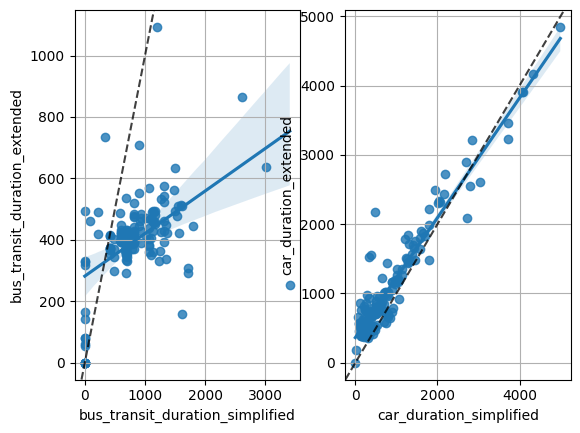

In [46]:
# Now compare the difference between trip duration in the simplified with average trip duration in the extended

zoi: str = "restrictedAv"  ## Choose between "allBologna" and "restrictedAv"
method: str = "simplified"
version: str = "20250926"

df_times_simplified_di = project.get_dataitem(f"otp_results_{method}_{zoi}_CAR_PARK_TRANSIT_v{version}")
df_times_simplified = df_times_simplified_di.as_df()
df_times_simplified["bus_transit_duration"] = df_times_simplified.apply(
    lambda row: get_duration_by_mode(row, ['BUS', 'TRANSIT']), axis=1
)
df_times_simplified["car_duration"] = df_times_simplified.apply(
    lambda row: get_duration_by_mode(row, ['CAR']), axis=1
)
df_times_simplified = df_times_simplified[['origin_lat', 'origin_lon', 'from', 'bus_transit_duration','car_duration']]

df_times_extended = (
    df_car_trans
    .groupby(['origin_lat', 'origin_lon', 'from'])
    [["bus_transit_duration", "car_duration"]]
    .mean()
    .reset_index()
)

df_merge = pd.merge(df_times_simplified, df_times_extended,
                    on=['origin_lat', 'origin_lon', 'from'], suffixes=["_simplified", "_extended"])

fig, ax = plt.subplots(ncols=2)

sns.regplot(data=df_merge, x="bus_transit_duration_simplified", y="bus_transit_duration_extended", ax=ax[0])
ax[0].grid()
ax[0].axline((1000,1000), slope=1, color='k', linestyle='--', alpha=0.75)

sns.regplot(data=df_merge, x="car_duration_simplified", y="car_duration_extended", ax=ax[1])
ax[1].grid()
ax[1].axline((0,0), slope=1, color='k', linestyle='--', alpha=0.75)

print("---------------BUS-----------------------------------------------------CAR----------------")
print("RMSE [seconds]:", 
      ((df_merge["bus_transit_duration_simplified"] - df_merge["bus_transit_duration_extended"])**2).mean()**(1/2),
      "                              ",
      ((df_merge["car_duration_simplified"] - df_merge["car_duration_extended"])**2).mean()**(1/2)
     )
print("MAE [seconds]:", 
      (df_merge["bus_transit_duration_simplified"] - df_merge["bus_transit_duration_extended"]).abs().mean(),
     "                               ",
     (df_merge["car_duration_simplified"] - df_merge["car_duration_extended"]).abs().mean()
     )

# The tended case increase the travel time by car, while decrease the travel time by transit in a significant way